___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright by Pierian Data Inc.</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Introduction to DBSCAN


Let's briefly explore visually the differences between DBSCAN and other clustering techniques, such as K-Means Clustering.

Visualizing DBSCAN Clustering tool that can help you understand how it works in a graphical way:
https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/

## DBSCAN and Clustering Examples

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
blobs = pd.read_csv('../DATA/cluster_blobs.csv')

In [3]:
blobs.head()

,X1,X2
0,4.645333,6.822294
1,4.784032,6.422883
2,-5.851786,5.774331
3,-7.459592,6.456415
4,4.918911,6.961479


<Axes: xlabel='X1', ylabel='X2'>

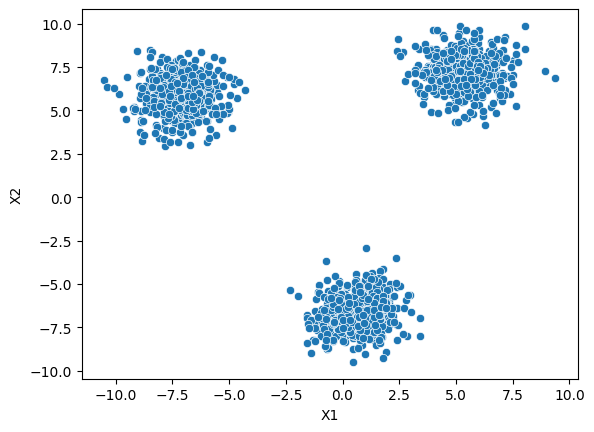

In [4]:
sns.scatterplot(data=blobs,x='X1',y='X2')

In [5]:
moons = pd.read_csv('../DATA/cluster_moons.csv')

In [6]:
moons.head()

,X1,X2
0,0.674362,-0.444625
1,1.547129,-0.239796
2,1.601930,-0.230792
3,0.014563,0.449752
4,1.503476,-0.389164


<Axes: xlabel='X1', ylabel='X2'>

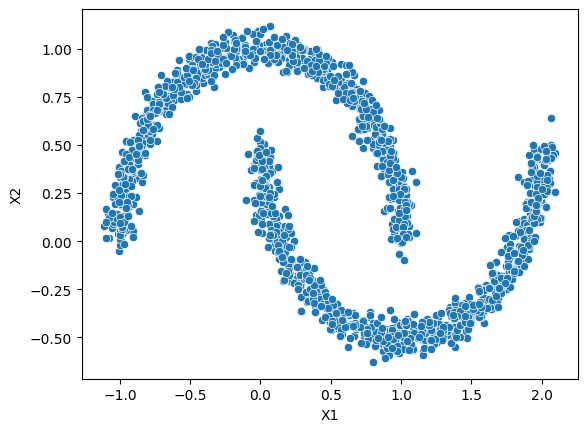

In [7]:
sns.scatterplot(data=moons,x='X1',y='X2')

In [8]:
circles = pd.read_csv('../DATA/cluster_circles.csv')

In [9]:
circles.head()

,X1,X2
0,-0.348677,0.010157
1,-0.176587,-0.954283
2,0.301703,-0.113045
3,-0.782889,-0.719468
4,-0.733280,-0.757354


<Axes: xlabel='X1', ylabel='X2'>

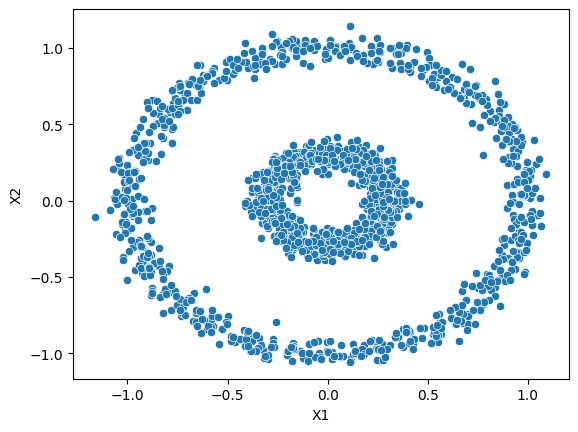

In [10]:
sns.scatterplot(data=circles,x='X1',y='X2')

## Label Discovery

In [11]:
def display_categories(model,data):
    labels = model.fit_predict(data)
    sns.scatterplot(data=data,x='X1',y='X2',hue=labels,palette='Set1')

## Kmeans Results

In [12]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters = 2)

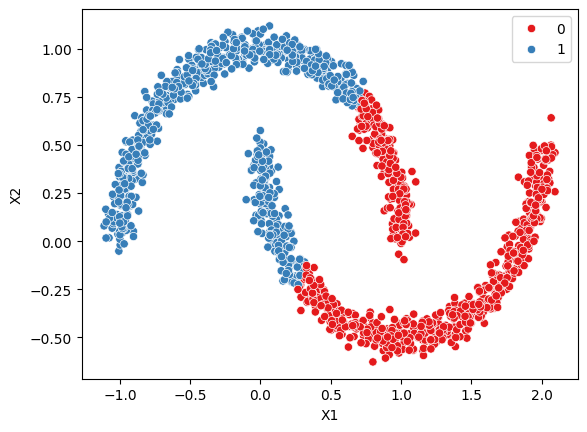

In [13]:
display_categories(model,moons)

Text(0, 0.5, ' Sum of Squared Distances')

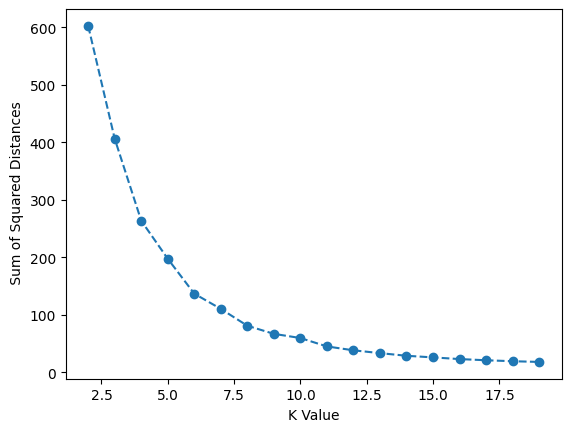

In [15]:
ssd = []
for k in range(2,20):
    model = KMeans(n_clusters=k)
    model.fit(moons)
    ssd.append(model.inertia_)
plt.plot(range(2,20),ssd,'o--')
plt.xlabel("K Value")
plt.ylabel(" Sum of Squared Distances")

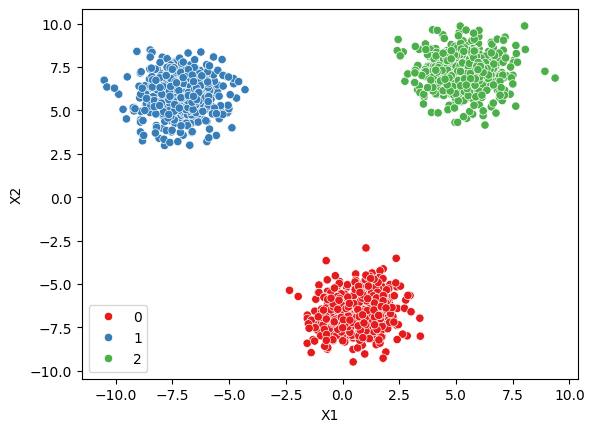

In [16]:
model = KMeans(n_clusters = 3)
display_categories(model,blobs)

Text(0, 0.5, ' Sum of Squared Distances')

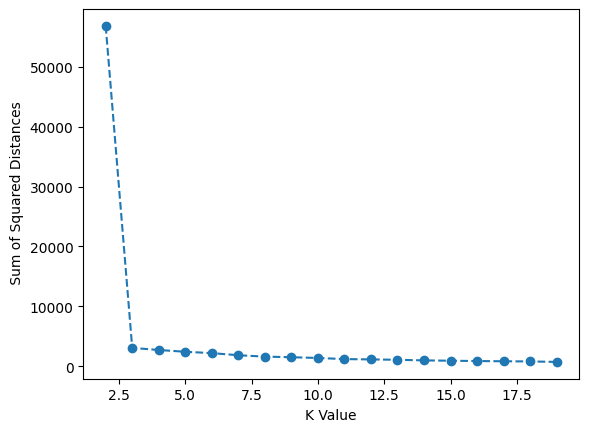

In [17]:
ssd = []
for k in range(2,20):
    model = KMeans(n_clusters=k)
    model.fit(blobs)
    ssd.append(model.inertia_)
plt.plot(range(2,20),ssd,'o--')
plt.xlabel("K Value")
plt.ylabel(" Sum of Squared Distances")

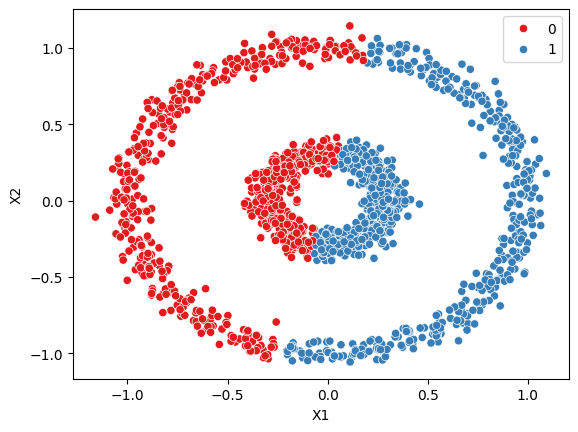

In [18]:
model = KMeans(n_clusters = 2)
display_categories(model,circles)

Text(0, 0.5, ' Sum of Squared Distances')

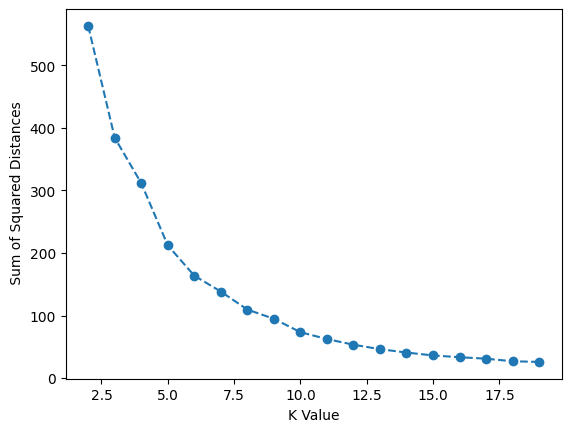

In [21]:
ssd = []
for k in range(2,20):
    model = KMeans(n_clusters=k)
    model.fit(circles)
    ssd.append(model.inertia_)
plt.plot(range(2,20),ssd,'o--')
plt.xlabel("K Value")
plt.ylabel(" Sum of Squared Distances")

## DBSCAN Results

In [22]:
from sklearn.cluster import DBSCAN

In [23]:
help(DBSCAN)

Help on class DBSCAN in module sklearn.cluster._dbscan:

class DBSCAN(sklearn.base.ClusterMixin, sklearn.base.BaseEstimator)
 |  DBSCAN(eps=0.5, *, min_samples=5, metric='euclidean', metric_params=None, algorithm='auto', leaf_size=30, p=None, n_jobs=None)
 |  
 |  Perform DBSCAN clustering from vector array or distance matrix.
 |  
 |  DBSCAN - Density-Based Spatial Clustering of Applications with Noise.
 |  Finds core samples of high density and expands clusters from them.
 |  This algorithm is particularly good for data which contains clusters of
 |  similar density and can find clusters of arbitrary shape.
 |  
 |  Unlike K-means, DBSCAN does not require specifying the number of clusters
 |  in advance and can identify outliers as noise points.
 |  
 |  This implementation has a worst case memory complexity of :math:`O({n}^2)`,
 |  which can occur when the `eps` param is large and `min_samples` is low,
 |  while the original DBSCAN only uses linear memory.
 |  For further details, s

In [24]:
model = DBSCAN(eps=0.6)

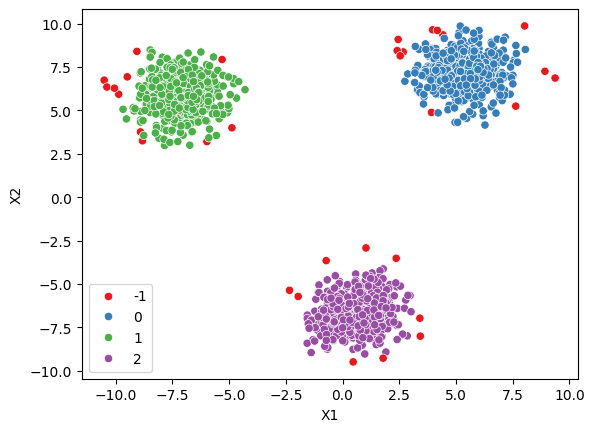

In [25]:
display_categories(model,blobs)

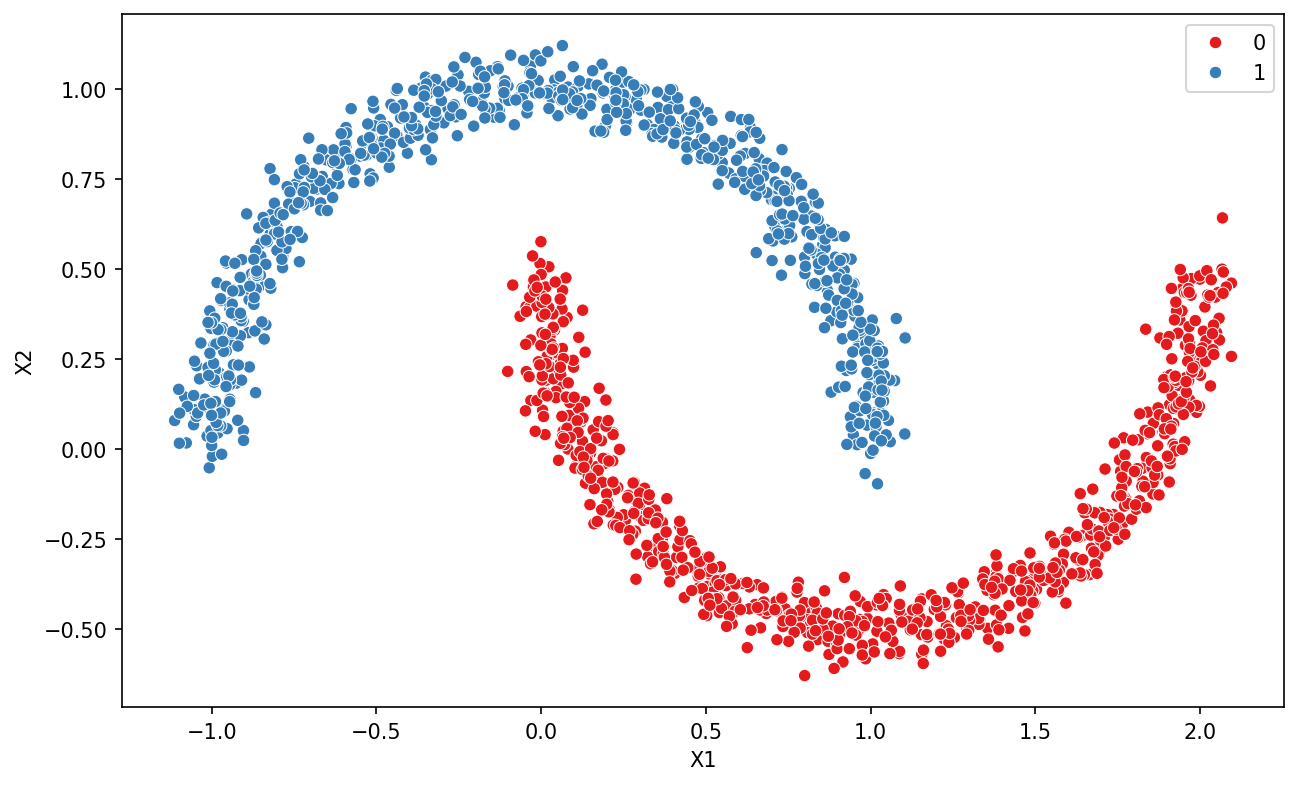

In [26]:
model = DBSCAN(eps=0.15)
plt.figure(figsize=(10,6),dpi=150)
display_categories(model,moons)

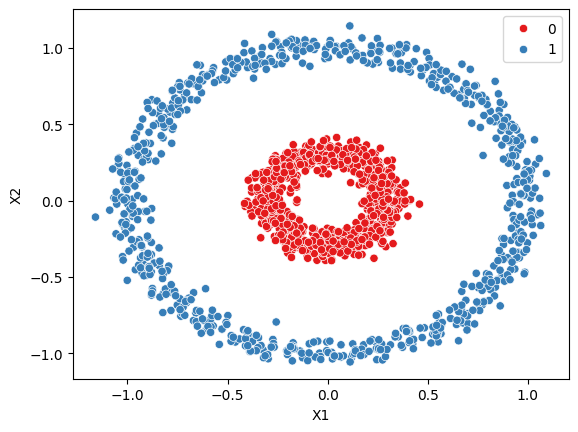

In [27]:
display_categories(model,circles)

Let's further explore DBSCAN Hyperparameters!

In [ ]:
# An important question here is which models are better for which datasets, and how do we know which model to use for a given dataset?
# The answer to this question is that it depends on the specific characteristics of the dataset and the goals of the analysis.
# KMeans is a good choice for datasets that have well-defined clusters that are roughly spherical in shape and have similar sizes. 
# KMeans works by minimizing the sum of squared distances between the data points and the cluster centers, 
# so it is sensitive to outliers and can struggle with clusters that have different shapes or sizes.
# DBSCAN, on the other hand, is a density-based clustering algorithm that can handle clusters of arbitrary shapes and sizes, and is less sensitive to outliers. 
# DBSCAN works by identifying dense regions of data points and grouping them together, so it can capture clusters that are not well-defined or that have different shapes or sizes.
# In general, if you have a dataset with well-defined clusters that are roughly spherical in shape and have similar sizes, KMeans may be a good choice. 
# If you have a dataset with clusters that are not well-defined or that have different shapes or sizes, DBSCAN may be a better choice. 
# However, it is always a good idea to try both algorithms and compare their results to see which one works best for your specific dataset and analysis goals.
# But if we have a dataset with many features and we want to use a clustering algorithm, we may need to use a dimensionality reduction technique, 
# like PCA, to reduce the number of features before applying the clustering algorithm. 